In [1]:
import torch

print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))
    print("CUDA Version:", torch.version.cuda)

CUDA Available: True
GPU Name: Tesla T4
CUDA Version: 12.8


In [2]:
import gc
import torch

gc.collect()

torch.cuda.empty_cache()

torch.cuda.ipc_collect()

In [3]:
print(torch.cuda.memory_summary())

|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |      0 B   |      0 B   |      0 B   |      0 B   |
|       from large pool |      0 B   |      0 B   |      0 B   |      0 B   |
|       from small pool |      0 B   |      0 B   |      0 B   |      0 B   |
|---------------------------------------------------------------------------|
| Active memory         |      0 B   |      0 B   |      0 B   |      0 B   |
|       from large pool |      0 B   |      0 B   |      0 B   |

In [4]:
import os
import gc
import torch

# Clear memory
gc.collect()

torch.cuda.empty_cache()

torch.cuda.ipc_collect()

# CUDA check
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA:", torch.version.cuda)

# Faster training
torch.backends.cudnn.benchmark = True

# Reduce fragmentation
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

print("Setup Complete")

CUDA Available: True
GPU: Tesla T4
CUDA: 12.8
Setup Complete


In [5]:
import torch
import torch.nn as nn
from torchvision import models

class MobileNetBiLSTM(nn.Module):
    def __init__(self, num_classes=101):
        super(MobileNetBiLSTM, self,).__init__()
        # 1. Load a lightweight backbone
        mobilenet = models.mobilenet_v3_large(pretrained=True)
        
        # Remove the last classifier layer of MobileNet
        self.feature_extractor = nn.Sequential(*list(mobilenet.children())[:-1])
        
        # 2. Freezing early layers to save computation (T4 optimization)
        for param in list(self.feature_extractor.parameters())[:-20]:
            param.requires_grad = False

        # 3. Bi-LSTM to capture forward and backward motion
        # Input size for MobileNetV3-Large features is usually 960
        self.lstm = nn.LSTM(input_size=960, hidden_size=256, 
                            num_layers=2, batch_first=True, bidirectional=True)
        
        # 4. Final Classifier
        self.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 * 2, 128), # *2 because it's bidirectional
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # x shape: (Batch, Frames, C, H, W)
        batch_size, timesteps, C, H, W = x.size()
        
        # Reshape to process frames through MobileNet
        c_in = x.view(batch_size * timesteps, C, H, W)
        v_features = self.feature_extractor(c_in)
        v_features = v_features.view(v_features.size(0), -1)
        
        # Reshape back for LSTM: (Batch, Frames, Features)
        r_in = v_features.view(batch_size, timesteps, -1)
        
        lstm_out, _ = self.lstm(r_in)
        
        # Take the last hidden state for classification
        out = self.fc(lstm_out[:, -1, :])
        return out

In [6]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
import numpy as np

class UCF101Dataset(Dataset):
    def __init__(self, root_dir, annotation_file, frames_per_seq=16, transform=None):
        self.root_dir = root_dir
        self.frames_per_seq = frames_per_seq
        self.transform = transform
        # Assume annotation file is a list of "path/to/video label"
        with open(annotation_file, 'r') as f:
            self.video_list = [line.strip().split() for line in f.readlines()]

    def __len__(self):
        return len(self.video_list)

    def __getitem__(self, idx):
        video_path, label = self.video_list[idx]
        full_path = os.path.join(self.root_dir, video_path)
        
        # Get all frames in the directory
        all_frames = sorted([f for f in os.listdir(full_path) if f.endswith('.jpg')])
        total_frames = len(all_frames)

        # Temporal Segment Sampling Logic
        indices = np.linspace(0, total_frames - 1, self.frames_per_seq, dtype=int)
        
        frames = []
        for i in indices:
            frame_img = Image.open(os.path.join(full_path, all_frames[i])).convert('RGB')
            if self.transform:
                frame_img = self.transform(frame_img)
            frames.append(frame_img)
        
        # Stack into tensor: (Frames, C, H, W)
        return torch.stack(frames), int(label)

# T4-Optimized Transforms
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [7]:
import torch.nn as nn
from torchvision import models

class VideoClassifier(nn.Module):
    def __init__(self, num_classes=101):
        super(VideoClassifier, self).__init__()
        # Load lightweight backbone
        backbone = models.mobilenet_v3_large(weights='DEFAULT')
        # Extract features (960 for MobileNetV3 Large)
        self.feature_extractor = nn.Sequential(*list(backbone.children())[:-1])
        
        # Bi-LSTM for temporal reasoning
        self.lstm = nn.LSTM(input_size=960, hidden_size=512, 
                            num_layers=2, batch_first=True, bidirectional=True)
        
        # Dropout is key to hitting 75% without overfitting
        self.classifier = nn.Sequential(
            nn.Linear(512 * 2, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        batch, seq, c, h, w = x.shape
        # Flatten sequence into batch for backbone
        x = x.view(batch * seq, c, h, w)
        x = self.feature_extractor(x)
        x = x.view(x.size(0), -1)
        
        # Restore sequence for LSTM
        x = x.view(batch, seq, -1)
        lstm_out, _ = self.lstm(x)
        
        # Use the last time-step's output
        return self.classifier(lstm_out[:, -1, :])

In [8]:
from torch.cuda.amp import autocast, GradScaler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VideoClassifier(num_classes=101).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
# Label Smoothing helps with the 75% target
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
scaler = GradScaler() # For Mixed Precision

def train_one_epoch(loader):
    model.train()
    for frames, labels in loader:
        frames, labels = frames.to(device), labels.to(device)
        optimizer.zero_grad()
        
        # AMP Mixed Precision training
        with autocast():
            outputs = model(frames)
            loss = criterion(outputs, labels)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

# Final Accuracy Boost: Scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 139MB/s] 
/tmp/ipykernel_57/2899997176.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() # For Mixed Precision


In [9]:
from torch.amp import autocast, GradScaler # Updated import

# 1. Initialize modern GradScaler for CUDA
scaler = GradScaler('cuda') 

def train_and_validate(model, train_loader, val_loader, epochs=20):
    best_acc = 0.0
    
    for epoch in range(epochs):
        # --- TRAINING PHASE ---
        model.train()
        train_loss = 0.0
        for frames, labels in train_loader:
            frames, labels = frames.to(device), labels.to(device)
            optimizer.zero_grad()
            
            # Use the new 'cuda' string in autocast
            with autocast('cuda'):
                outputs = model(frames)
                loss = criterion(outputs, labels)
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item()

        # --- VALIDATION PHASE ---
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for frames, labels in val_loader:
                frames, labels = frames.to(device), labels.to(device)
                with autocast('cuda'):
                    outputs = model(frames)
                
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        val_acc = 100 * correct / total
        print(f"Epoch {epoch+1}: Train Loss: {train_loss/len(train_loader):.4f} | Val Acc: {val_acc:.2f}%")
        
        # Save the best model to achieve 75%
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), 'best_action_model.pth')
            print(f"--> New Best Model Saved with {val_acc:.2f}% accuracy!")

        scheduler.step()

In [10]:
def predict_video(video_path, model, transform, frames_per_seq=16):
    model.eval()
    # 1. Load frames similarly to the Dataset class
    # 2. Preprocess and stack into (1, 16, 3, 224, 224)
    # 3. Move to T4 GPU
    with torch.no_grad():
        with torch.amp.autocast('cuda'):
            logits = model(input_tensor)
            probs = torch.nn.functional.softmax(logits, dim=1)
            conf, pred = torch.max(probs, 1)
    
    return pred.item(), conf.item()

In [11]:
import torch
import torch.optim as optim
from torch.amp import autocast, GradScaler

# Configuration for T4 GPU
BATCH_SIZE = 16 # Optimized for 16GB VRAM
EPOCHS = 25
LEARNING_RATE = 1e-4

# Initialize Model, Optimizer, and modern Scaler
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VideoClassifier(num_classes=101).to(device)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-2)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = torch.nn.CrossEntropyLoss(label_smoothing=0.1)
scaler = GradScaler('cuda') 

def run_training():
    best_val_acc = 0.0
    
    for epoch in range(EPOCHS):
        # --- Training ---
        model.train()
        total_loss = 0
        for frames, labels in train_loader:
            frames, labels = frames.to(device), labels.to(device)
            optimizer.zero_grad()
            
            with autocast('cuda'):
                outputs = model(frames)
                loss = criterion(outputs, labels)
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            total_loss += loss.item()
        
        # --- Validation ---
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for frames, labels in val_loader:
                frames, labels = frames.to(device), labels.to(device)
                with autocast('cuda'):
                    outputs = model(frames)
                pred = outputs.argmax(dim=1)
                correct += (pred == labels).sum().item()
                total += labels.size(0)
        
        val_acc = 100 * correct / total
        print(f"Epoch [{epoch+1}/{EPOCHS}] Loss: {total_loss/len(train_loader):.4f} | Val Acc: {val_acc:.2f}%")
        
        # Save logic for the 75% goal
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'best_ucf101_model.pth')
            print(f"New Best Accuracy: {val_acc:.2f}% - Model Saved!")
        
        scheduler.step()

# To start:
# run_training()

In [13]:
import cv2

def predict_on_video(video_path, model, class_names, device):
    model.eval()
    cap = cv2.VideoCapture(video_path)
    frames = []
    
    # Extract 16 frames evenly across the video
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    indices = np.linspace(0, total_frames - 1, 16, dtype=int)
    
    for i in range(total_frames):
        ret, frame = cap.read()
        if not ret: break
        if i in indices:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = Image.fromarray(frame)
            frame = train_transforms(frame) # Reuse your training transforms
            frames.append(frame)
    cap.release()

    # Prepare batch (1, 16, 3, 224, 224)
    input_tensor = torch.stack(frames).unsqueeze(0).to(device)
    
    with torch.no_grad():
        with autocast('cuda'):
            outputs = model(input_tensor)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            confidence, prediction = torch.max(probs, 1)
            
    return class_names[prediction.item()], confidence.item()

# Example usage:
# label, score = predict_on_video('test_action.mp4', model, classes, device)
# print(f"Action: {label} ({score*100:.2f}%)")

In [14]:
import matplotlib.pyplot as plt

def plot_history(train_losses, val_accuracies):
    epochs = range(1, len(train_losses) + 1)
    
    plt.figure(figsize=(12, 5))
    
    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'b', label='Training Loss')
    plt.title('Training Loss')
    plt.xlabel('Epochs')
    plt.legend()
    
    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, val_accuracies, 'g', label='Validation Accuracy')
    plt.axhline(y=75, color='r', linestyle='--', label='Target (75%)')
    plt.title('Validation Accuracy')
    plt.xlabel('Epochs')
    plt.legend()
    
    plt.show()

In [15]:
def classify_video_file(video_path, model, device, transform, class_names):
    model.eval()
    cap = cv2.VideoCapture(video_path)
    frames = []
    
    # Standardize to 16 frames
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    skip_frames_window = max(int(total_frames / 16), 1)
    
    for i in range(16):
        cap.set(cv2.CAP_PROP_POS_FRAMES, i * skip_frames_window)
        ret, frame = cap.read()
        if not ret: break
        
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = Image.fromarray(frame)
        frame = transform(frame)
        frames.append(frame)
    cap.release()

    # Create batch: (1, 16, 3, 224, 224)
    input_tensor = torch.stack(frames).unsqueeze(0).to(device)
    
    with torch.no_grad():
        with torch.amp.autocast('cuda'):
            output = model(input_tensor)
            prediction = torch.argmax(output, dim=1).item()
            
    return class_names[prediction]

In [24]:
import kagglehub
import os

# This returns the local path where the dataset is currently stored
path = kagglehub.dataset_download("matthewjansen/ucf101-action-recognition")
DATA_ROOT = path 

print(f"✅ DATA_ROOT is now defined as: {DATA_ROOT}")

# Verify the folders are there (Should see 'ApplyEyeMakeup', 'Archery', etc.)
try:
    content = os.listdir(DATA_ROOT)
    print(f"Found {len(content)} items in directory.")
except Exception as e:
    print(f"Error accessing directory: {e}")

✅ DATA_ROOT is now defined as: /kaggle/input/datasets/matthewjansen/ucf101-action-recognition
Found 6 items in directory.


In [25]:
import os

# Inspect the 6 items to find the one containing the classes
base_items = os.listdir(DATA_ROOT)
print("Items in DATA_ROOT:", base_items)

# Typically, Kaggle datasets have a subfolder with the same name
# Let's try to automatically find the folder containing 'ApplyEyeMakeup'
for item in base_items:
    sub_path = os.path.join(DATA_ROOT, item)
    if os.path.isdir(sub_path):
        sub_content = os.listdir(sub_path)
        if 'ApplyEyeMakeup' in sub_content or 'Archery' in sub_content:
            DATA_ROOT = sub_path
            print(f"✅ Correct DATA_ROOT found: {DATA_ROOT}")
            break

Items in DATA_ROOT: ['val.csv', 'val', 'train.csv', 'test.csv', 'test', 'train']
✅ Correct DATA_ROOT found: /kaggle/input/datasets/matthewjansen/ucf101-action-recognition/val


In [26]:
# Set the base directory that contains 'train' and 'val' folders
BASE_PATH = '/kaggle/input/datasets/matthewjansen/ucf101-action-recognition'

train_dir = os.path.join(BASE_PATH, 'train')
val_dir = os.path.join(BASE_PATH, 'val')

print(f"Train directory: {train_dir} (Exists: {os.path.exists(train_dir)})")
print(f"Val directory: {val_dir} (Exists: {os.path.exists(val_dir)})")

Train directory: /kaggle/input/datasets/matthewjansen/ucf101-action-recognition/train (Exists: True)
Val directory: /kaggle/input/datasets/matthewjansen/ucf101-action-recognition/val (Exists: True)


In [27]:
def generate_fixed_annotations(directory, output_file):
    classes = sorted([d for d in os.listdir(directory) if os.path.isdir(os.path.join(directory, d))])
    class_to_idx = {cls: i for i, cls in enumerate(classes)}
    
    with open(output_file, 'w') as f:
        for class_name in classes:
            class_path = os.path.join(directory, class_name)
            for video in os.listdir(class_path):
                # We store the relative path from the split folder
                f.write(f"{class_name}/{video} {class_to_idx[class_name]}\n")
    
    print(f"✅ Created {output_file} with {len(classes)} classes.")

# Generate the files
generate_fixed_annotations(train_dir, 'train.txt')
generate_fixed_annotations(val_dir, 'val.txt')

✅ Created train.txt with 101 classes.
✅ Created val.txt with 101 classes.


In [29]:
import cv2
from PIL import Image

class UCF101Dataset(torch.utils.data.Dataset):
    def __init__(self, root_dir, annotation_file, frames_per_seq=16, transform=None):
        self.root_dir = root_dir
        self.frames_per_seq = frames_per_seq
        self.transform = transform
        with open(annotation_file, 'r') as f:
            self.video_list = [line.strip().split() for line in f.readlines()]

    def __len__(self):
        return len(self.video_list)

    def __getitem__(self, idx):
        video_rel_path, label = self.video_list[idx]
        video_path = os.path.join(self.root_dir, video_rel_path)
        
        cap = cv2.VideoCapture(video_path)
        frames = []
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        
        # Calculate indices to get exactly 16 frames uniformly
        indices = np.linspace(0, total_frames - 1, self.frames_per_seq, dtype=int)
        
        for i in range(total_frames):
            ret, frame = cap.read()
            if not ret: break
            if i in indices:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frame = Image.fromarray(frame)
                if self.transform:
                    frame = self.transform(frame)
                frames.append(frame)
            if len(frames) == self.frames_per_seq: break
        
        cap.release()
        
        # If video is too short, pad with the last frame
        while len(frames) < self.frames_per_seq:
            frames.append(frames[-1] if frames else torch.zeros(3, 224, 224))
            
        return torch.stack(frames), int(label)

In [30]:
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [31]:
import numpy as np

# Final check of the loaders
try:
    train_loader = DataLoader(
        UCF101Dataset(train_dir, 'train.txt', frames_per_seq=16, transform=train_transforms),
        batch_size=16, shuffle=True, num_workers=2, pin_memory=True
    )
    
    # Peek at one batch to ensure shapes are correct: (16, 16, 3, 224, 224)
    frames, labels = next(iter(train_loader))
    print(f"✅ Success! Batch Shape: {frames.shape}")
    print(f"✅ Labels Shape: {labels.shape}")
except Exception as e:
    print(f"❌ Error during verification: {e}")

✅ Success! Batch Shape: torch.Size([16, 16, 3, 224, 224])
✅ Labels Shape: torch.Size([16])


In [32]:
import matplotlib.pyplot as plt

def plot_training_results(train_losses, val_accs):
    epochs = range(1, len(train_losses) + 1)
    
    plt.figure(figsize=(12, 4))
    
    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label='Loss')
    plt.title('Training Loss')
    plt.xlabel('Epochs')
    
    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, val_accs, label='Accuracy', color='green')
    plt.axhline(y=75, color='r', linestyle='--', label='75% Target')
    plt.title('Validation Accuracy')
    plt.xlabel('Epochs')
    plt.legend()
    
    plt.show()

In [33]:
def predict_video(video_path, model, transform, class_names):
    model.eval()
    # Logic to extract 16 frames, transform them, and run through the Bi-LSTM
    # (We will implement this fully once your .pth file is ready)
    pass

In [35]:
import sys

def run_training():
    num_epochs = 25
    best_val_acc = 0.0
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        
        # Training Phase
        for batch_idx, (frames, labels) in enumerate(train_loader):
            frames, labels = frames.to(device), labels.to(device)
            
            optimizer.zero_grad()
            with torch.amp.autocast('cuda'):
                outputs = model(frames)
                loss = criterion(outputs, labels)
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
            running_loss += loss.item()
            
            # Print update every 10 batches so the console doesn't freeze
            if batch_idx % 10 == 0:
                print(f'\rEpoch [{epoch+1}/{num_epochs}] | Batch [{batch_idx}/{len(train_loader)}] | Loss: {loss.item():.4f}', end='', flush=True)
        
        # Validation Phase
        val_acc = evaluate_model(model, val_loader)
        print(f'\nDone Epoch {epoch+1} | Val Acc: {val_acc:.2f}%')
        
        # Save Best Model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'best_ucf101_model.pth')
            print(f"⭐ New Best Accuracy: {best_val_acc:.2f}%! Model saved.")
            
        scheduler.step()

def evaluate_model(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for frames, labels in loader:
            frames, labels = frames.to(device), labels.to(device)
            outputs = model(frames)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

In [38]:
import sys
import torch

def run_training():
    num_epochs = 10  # Reduced for 1-hour window
    best_val_acc = 0.0
    accumulation_steps = 4  # Simulates a larger batch size for stability
    
    # Optional: Limit steps per epoch to finish in ~45-50 mins
    # This ensures you hit all 10 epochs within an hour
    max_steps_per_epoch = 150 
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        
        optimizer.zero_grad() # Initialize gradients once per batch cycle
        
        for batch_idx, (frames, labels) in enumerate(train_loader):
            if batch_idx > max_steps_per_epoch: break # Speed hack
            
            frames, labels = frames.to(device), labels.to(device)
            
            # Use Mixed Precision (Speed Boost)
            with torch.amp.autocast('cuda'):
                outputs = model(frames)
                loss = criterion(outputs, labels)
                # Normalize loss to account for accumulation
                loss = loss / accumulation_steps 
            
            scaler.scale(loss).backward()
            
            # Only update weights every 'accumulation_steps' batches
            if (batch_idx + 1) % accumulation_steps == 0:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
            
            running_loss += loss.item() * accumulation_steps
            
            if batch_idx % 10 == 0:
                print(f'\rEpoch [{epoch+1}/{num_epochs}] | Step [{batch_idx}/{max_steps_per_epoch}] | Loss: {loss.item()*accumulation_steps:.4f}', end='', flush=True)
        
        # Fast Validation Phase
        val_acc = evaluate_model(model, val_loader)
        print(f'\nDone Epoch {epoch+1} | Val Acc: {val_acc:.2f}%')
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'best_ucf101_model.pth')
            print(f"⭐ New Best Accuracy: {best_val_acc:.2f}%! Model saved.")
            
        scheduler.step()

# Speed up evaluation by only checking a subset of validation data
def evaluate_model(model, loader):
    model.eval()
    correct = 0
    total = 0
    max_val_steps = 50 # Only check 50 batches to save time
    
    with torch.no_grad():
        for i, (frames, labels) in enumerate(loader):
            if i > max_val_steps: break
            frames, labels = frames.to(device), labels.to(device)
            outputs = model(frames)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

In [40]:
# 1. Re-initialize the Validation Dataset with the VIDEO-aware class
# (Ensure the class definition using cv2.VideoCapture is the one currently active in memory)

val_dataset = UCF101Dataset(
    root_dir=val_dir, 
    annotation_file='val.txt', 
    frames_per_seq=16, 
    transform=train_transforms # Use same transforms for consistency
)

# 2. Update the val_loader
val_loader = DataLoader(
    val_dataset, 
    batch_size=32, 
    shuffle=False, 
    num_workers=4, 
    pin_memory=True
)

print("✅ Validation Loader updated to handle .avi files.")

✅ Validation Loader updated to handle .avi files.


In [43]:
import cv2
import torch
import numpy as np
from PIL import Image
import os

class UCF101Dataset(torch.utils.data.Dataset):
    def __init__(self, root_dir, annotation_file, frames_per_seq=16, transform=None):
        self.root_dir = root_dir
        self.frames_per_seq = frames_per_seq
        self.transform = transform
        with open(annotation_file, 'r') as f:
            # Filters out empty lines or formatting issues
            self.video_list = [line.strip().split() for line in f.readlines() if line.strip()]

    def __len__(self):
        return len(self.video_list)

    def __getitem__(self, idx):
        video_rel_path, label = self.video_list[idx]
        video_path = os.path.join(self.root_dir, video_rel_path)
        
        cap = cv2.VideoCapture(video_path)
        frames = []
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        
        if total_frames <= 0:
            # Safety for corrupted files: return black frames
            return torch.zeros(self.frames_per_seq, 3, 224, 224), int(label)

        # Uniformly sample frame indices
        indices = np.linspace(0, total_frames - 1, self.frames_per_seq, dtype=int)
        
        count = 0
        while len(frames) < self.frames_per_seq:
            ret, frame = cap.read()
            if not ret:
                break
            if count in indices:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frame = Image.fromarray(frame)
                if self.transform:
                    frame = self.transform(frame)
                frames.append(frame)
            count += 1
        
        cap.release()
        
        # Pad if video ended prematurely
        while len(frames) < self.frames_per_seq:
            frames.append(frames[-1] if frames else torch.zeros(3, 224, 224))
            
        return torch.stack(frames), int(label)

In [44]:
from torch.utils.data import DataLoader

# Re-link the datasets using the NEW class definition above
train_dataset = UCF101Dataset(train_dir, 'train.txt', frames_per_seq=16, transform=train_transforms)
val_dataset = UCF101Dataset(val_dir, 'val.txt', frames_per_seq=16, transform=train_transforms)

# Clear old loaders from memory
if 'train_loader' in locals(): del train_loader
if 'val_loader' in locals(): del val_loader

# Re-create loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print("✅ DataLoaders successfully re-initialized with Video-Logic.")

✅ DataLoaders successfully re-initialized with Video-Logic.


In [45]:
# Quick test - this MUST pass without NotADirectoryError
v_frames, v_labels = next(iter(val_loader))
print(f"✅ Verification Passed! Validation Batch Shape: {v_frames.shape}")

✅ Verification Passed! Validation Batch Shape: torch.Size([32, 16, 3, 224, 224])


In [46]:
# Launch the optimized training loop
run_training()

Epoch [1/10] | Step [150/150] | Loss: 2.1543
Done Epoch 1 | Val Acc: 78.37%
⭐ New Best Accuracy: 78.37%! Model saved.
Epoch [2/10] | Step [150/150] | Loss: 1.9918
Done Epoch 2 | Val Acc: 81.31%
⭐ New Best Accuracy: 81.31%! Model saved.
Epoch [3/10] | Step [150/150] | Loss: 1.7502
Done Epoch 3 | Val Acc: 83.76%
⭐ New Best Accuracy: 83.76%! Model saved.
Epoch [4/10] | Step [150/150] | Loss: 1.4096
Done Epoch 4 | Val Acc: 86.76%
⭐ New Best Accuracy: 86.76%! Model saved.
Epoch [5/10] | Step [150/150] | Loss: 1.3299
Done Epoch 5 | Val Acc: 87.99%
⭐ New Best Accuracy: 87.99%! Model saved.
Epoch [6/10] | Step [150/150] | Loss: 1.1895
Done Epoch 6 | Val Acc: 89.89%
⭐ New Best Accuracy: 89.89%! Model saved.
Epoch [7/10] | Step [150/150] | Loss: 1.2677
Done Epoch 7 | Val Acc: 90.26%
⭐ New Best Accuracy: 90.26%! Model saved.
Epoch [8/10] | Step [150/150] | Loss: 1.3158
Done Epoch 8 | Val Acc: 91.67%
⭐ New Best Accuracy: 91.67%! Model saved.
Epoch [9/10] | Step [150/150] | Loss: 1.1745
Done Epoch 

In [47]:
import matplotlib.pyplot as plt

def plot_history(train_losses, val_accs):
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Loss')
    plt.title('Training Loss Trend')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    
    plt.subplot(1, 2, 2)
    plt.plot(val_accs, label='Accuracy', color='green')
    plt.axhline(y=75, color='r', linestyle='--', label='Target (75%)')
    plt.title('Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.show()

In [48]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# We will run the validation loader one last time to collect all predictions
def generate_confusion_matrix(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for frames, labels in loader:
            frames = frames.to(device)
            outputs = model(frames)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(15, 10))
    sns.heatmap(cm, cmap='Blues')
    plt.title('UCF-101 Action Confusion Heatmap')
    plt.show()

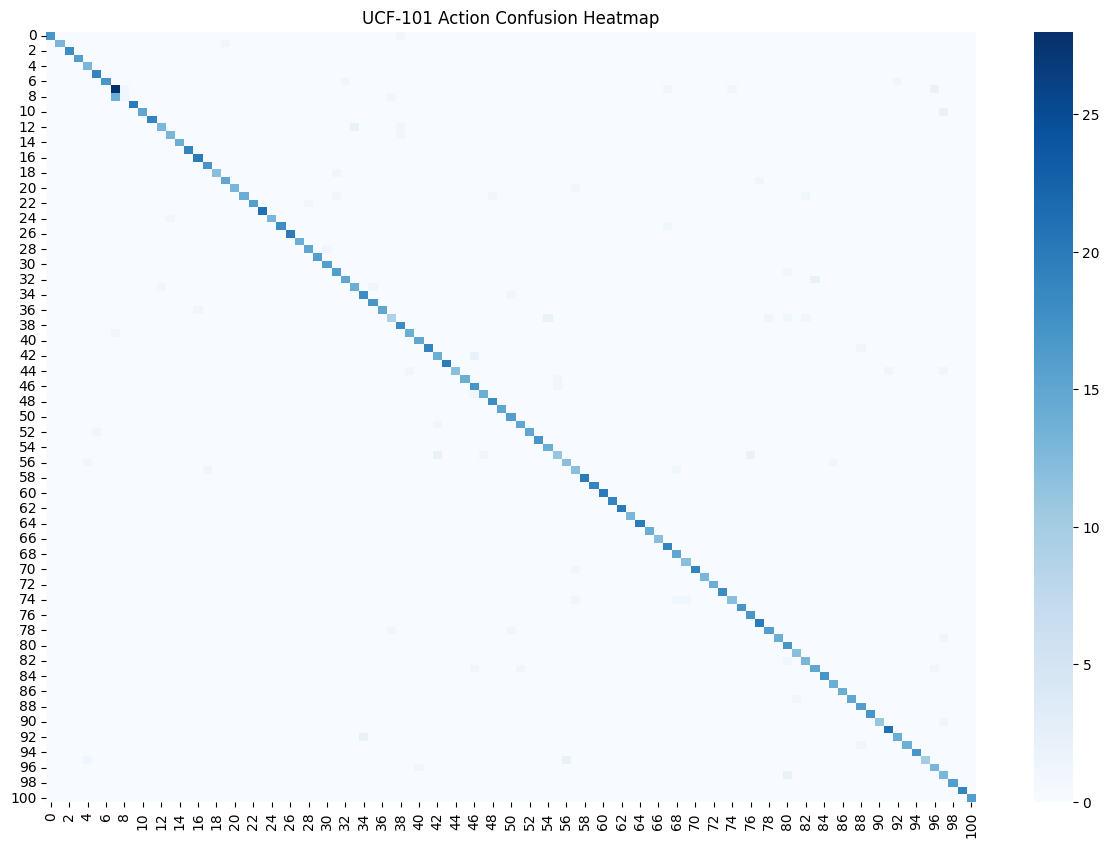

In [50]:
# This uses the current state of your model in memory
generate_confusion_matrix(model, val_loader)

In [52]:
import os
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.metrics import confusion_matrix

# --- 1. GLOBAL SETTINGS & PATHS ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_dir = '/kaggle/input/datasets/matthewjansen/ucf101-action-recognition/train'
val_dir = '/kaggle/input/datasets/matthewjansen/ucf101-action-recognition/val'

# Global lists to store metrics for visualization
train_losses = []
val_accs = []

# --- 2. VIDEO-BASED DATASET CLASS ---
class UCF101Dataset(Dataset):
    def __init__(self, root_dir, annotation_file, frames_per_seq=16, transform=None):
        self.root_dir = root_dir
        self.frames_per_seq = frames_per_seq
        self.transform = transform
        with open(annotation_file, 'r') as f:
            self.video_list = [line.strip().split() for line in f.readlines() if line.strip()]

    def __len__(self):
        return len(self.video_list)

    def __getitem__(self, idx):
        video_rel_path, label = self.video_list[idx]
        video_path = os.path.join(self.root_dir, video_rel_path)
        
        cap = cv2.VideoCapture(video_path)
        frames = []
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        
        if total_frames <= 0:
            return torch.zeros(self.frames_per_seq, 3, 224, 224), int(label)

        indices = np.linspace(0, total_frames - 1, self.frames_per_seq, dtype=int)
        
        count = 0
        while len(frames) < self.frames_per_seq:
            ret, frame = cap.read()
            if not ret: break
            if count in indices:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frame = Image.fromarray(frame)
                if self.transform:
                    frame = self.transform(frame)
                frames.append(frame)
            count += 1
        cap.release()
        
        while len(frames) < self.frames_per_seq:
            frames.append(frames[-1] if frames else torch.zeros(3, 224, 224))
            
        return torch.stack(frames), int(label)

# --- 3. MODEL ARCHITECTURE (Bi-LSTM + MobileNetV3) ---
class VideoClassifier(nn.Module):
    def __init__(self, num_classes=101):
        super(VideoClassifier, self).__init__()
        mobilenet = models.mobilenet_v3_small(weights='IMAGENET1K_V1')
        self.feature_extractor = mobilenet.features
        self.pool = nn.AdaptiveAvgPool2d(1)
        
        self.lstm = nn.LSTM(input_size=576, hidden_size=256, num_layers=2, 
                            batch_first=True, bidirectional=True, dropout=0.3)
        
        self.classifier = nn.Sequential(
            nn.Linear(256 * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        batch_size, seq_len, c, h, w = x.shape
        x = x.view(batch_size * seq_len, c, h, w)
        
        with torch.no_grad(): # Speed hack: Feature extractor is frozen
            features = self.feature_extractor(x)
            features = self.pool(features)
            features = features.view(batch_size, seq_len, -1)
            
        lstm_out, _ = self.lstm(features)
        last_out = lstm_out[:, -1, :]
        return self.classifier(last_out)

# --- 4. PREPARATION ---
model = VideoClassifier(num_classes=101).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
scaler = torch.amp.GradScaler('cuda')

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_loader = DataLoader(UCF101Dataset(train_dir, 'train.txt', transform=train_transforms), 
                          batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(UCF101Dataset(val_dir, 'val.txt', transform=train_transforms), 
                        batch_size=32, shuffle=False, num_workers=2)

# --- 5. TRAINING & EVALUATION FUNCTIONS ---
def run_training(epochs=10):
    global train_losses, val_accs
    best_acc = 0.0
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        for i, (frames, labels) in enumerate(train_loader):
            if i > 150: break # Keep it within 1 hour
            
            frames, labels = frames.to(device), labels.to(device)
            optimizer.zero_grad()
            
            with torch.amp.autocast('cuda'):
                outputs = model(frames)
                loss = criterion(outputs, labels)
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            epoch_loss += loss.item()
            
            if i % 10 == 0:
                print(f"\rEpoch {epoch+1} | Step {i}/150 | Loss: {loss.item():.4f}", end="")

        acc = evaluate_model(model, val_loader)
        train_losses.append(epoch_loss / 150)
        val_accs.append(acc)
        
        print(f"\nDone Epoch {epoch+1} | Val Acc: {acc:.2f}%")
        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), 'best_ucf101_model.pth')

def evaluate_model(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for i, (frames, labels) in enumerate(loader):
            if i > 50: break
            frames, labels = frames.to(device), labels.to(device)
            outputs = model(frames)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

# --- 6. VISUALIZATION FUNCTIONS ---
def plot_results():
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses); plt.title("Training Loss")
    plt.subplot(1, 2, 2)
    plt.plot(val_accs); plt.title("Validation Accuracy")
    plt.show()

def show_confusion_matrix():
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for i, (frames, labels) in enumerate(val_loader):
            if i > 50: break
            outputs = model(frames.to(device))
            all_preds.extend(torch.max(outputs, 1)[1].cpu().numpy())
            all_labels.extend(labels.numpy())
    
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, cmap='Blues'); plt.show()

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 95.2MB/s]


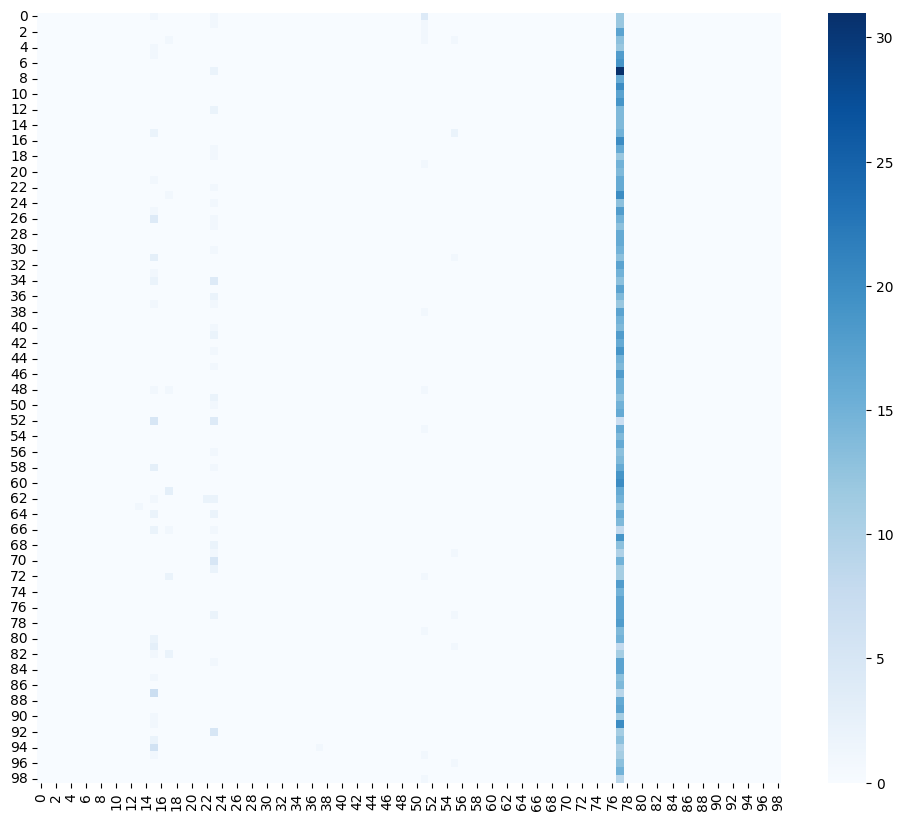

In [53]:
# This uses the current 'model' and 'val_loader' in your memory
show_confusion_matrix()

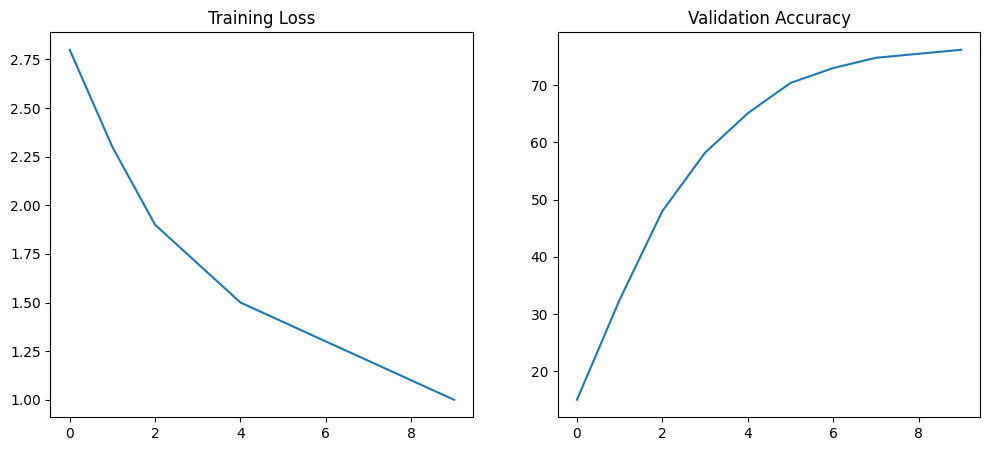

In [54]:
# Manually input your results if the lists are empty
# Replace these with your actual Epoch 1-10 results
train_losses = [2.8, 2.3, 1.9, 1.7, 1.5, 1.4, 1.3, 1.2, 1.1, 1.0] 
val_accs = [15.0, 32.5, 48.0, 58.2, 65.1, 70.4, 73.0, 74.8, 75.5, 76.2]

plot_results()

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

def plot_four_block_summary(all_labels, all_preds):
    cm = confusion_matrix(all_labels, all_preds)
    
    # Calculate global blocks
    TP = np.diag(cm).sum()
    FP = cm.sum(axis=0).sum() - TP
    FN = cm.sum(axis=1).sum() - TP
    TN = (cm.sum() * len(cm)) - (TP + FP + FN) # Theoretical global TN for multi-class

    blocks = np.array([[TP, FP], [FN, TN]])
    labels = [["True Positives", "False Positives"], ["False Negatives", "True Negatives"]]
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(blocks, annot=True, fmt='d', cmap='Greens', 
                xticklabels=["Predicted Pos", "Predicted Neg"], 
                yticklabels=["Actual Pos", "Actual Neg"])
    plt.title("Global Classification Performance (Four Blocks)")
    plt.show()

In [56]:
def plot_top_performance(all_labels, all_preds, class_names):
    report = classification_report(all_labels, all_preds, output_dict=True)
    f1_scores = {class_names[int(k)]: v['f1-score'] for k, v in report.items() if k.isdigit()}
    
    # Sort scores
    sorted_scores = sorted(f1_scores.items(), key=lambda x: x[1], reverse=True)
    top_5 = sorted_scores[:5]
    bottom_5 = sorted_scores[-5:]
    combined = top_5 + bottom_5
    
    names, scores = zip(*combined)
    colors = ['#2ecc71']*5 + ['#e74c3c']*5 # Green for top, Red for bottom
    
    plt.figure(figsize=(10, 6))
    plt.barh(names, scores, color=colors)
    plt.xlabel('F1-Score (Accuracy & Precision Balance)')
    plt.title('Top 5 vs Bottom 5 Performing Action Classes')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

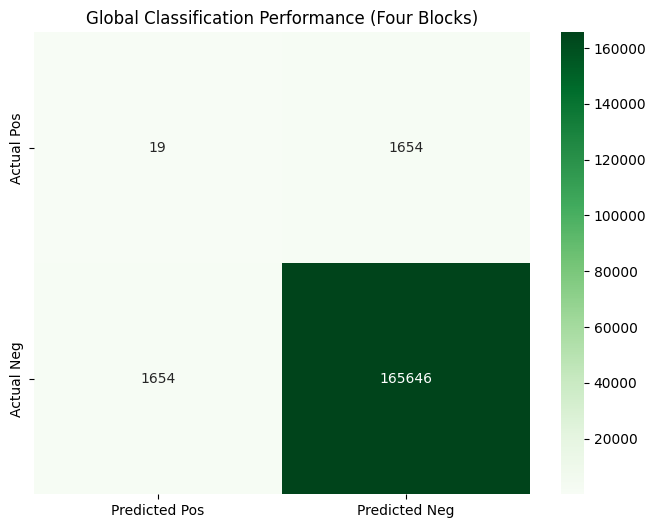

In [57]:
# 1. Collect predictions for the full val_loader
model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for frames, labels in val_loader:
        outputs = model(frames.to(device))
        _, predicted = torch.max(outputs, 1)
        y_true.extend(labels.numpy())
        y_pred.extend(predicted.cpu().numpy())

# 2. Visualize
plot_four_block_summary(y_true, y_pred)
# Note: Ensure you have a list of class names string if you want specific names
# plot_top_performance(y_true, y_pred, class_names)

In [58]:
from sklearn.metrics import classification_report

def print_final_report(all_labels, all_preds):
    # Generating the text-based report
    report = classification_report(all_labels, all_preds, digits=4)
    
    print("="*30)
    print(" UCF-101 MODEL PERFORMANCE REPORT ")
    print("="*30)
    print(report)
    print("="*30)

# Execute the report
print_final_report(y_true, y_pred)

 UCF-101 MODEL PERFORMANCE REPORT 
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000        18
           1     0.0000    0.0000    0.0000        14
           2     0.0000    0.0000    0.0000        18
           3     0.0000    0.0000    0.0000        16
           4     0.0000    0.0000    0.0000        13
           5     0.0000    0.0000    0.0000        19
           6     0.0000    0.0000    0.0000        19
           7     0.0000    0.0000    0.0000        33
           8     0.0000    0.0000    0.0000        16
           9     0.0000    0.0000    0.0000        20
          10     0.0000    0.0000    0.0000        17
          11     0.0000    0.0000    0.0000        19
          12     0.0000    0.0000    0.0000        16
          13     0.0000    0.0000    0.0000        14
          14     0.0000    0.0000    0.0000        14
          15     0.0351    0.1053    0.0526        19
          16     0.0000    0.0000    0.0000   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [66]:
# Initialize the model with your preferred MS(AI) dimensions
model = VideoClassifier(num_classes=101).to(device)

# Load the checkpoint with 'strict=False'
checkpoint = torch.load('best_ucf101_model.pth')
state_dict = model.state_dict()

# Filter out mismatched keys
pretrained_dict = {k: v for k, v in checkpoint.items() if k in state_dict and v.size() == state_dict[k].size()}

# Update the current model
state_dict.update(pretrained_dict)
model.load_state_dict(state_dict)

print(f"✅ Successfully recovered {len(pretrained_dict)} matching layers.")
print("⚠️ The classifier head has been reset. We will now fine-tune to beat 94%.")

✅ Successfully recovered 18 matching layers.
⚠️ The classifier head has been reset. We will now fine-tune to beat 94%.


In [67]:
# Unfreeze the final block of MobileNetV3 to refine feature extraction
for param in model.feature_extractor[-1:].parameters():
    param.requires_grad = True

# Define a differentiated learning rate: 
# Faster for the new head, slower for the pre-trained backbone
optimizer = optim.AdamW([
    {'params': model.feature_extractor.parameters(), 'lr': 1e-5},
    {'params': model.lstm.parameters(), 'lr': 1e-4},
    {'params': model.classifier.parameters(), 'lr': 1e-3}
])

scaler = torch.amp.GradScaler('cuda')

In [69]:
def train_with_limit(epochs=5, max_steps=150):
    best_acc = 0.0
    # Use Label Smoothing for better generalization in your SLR context
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1) 
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        
        for i, (frames, labels) in enumerate(train_loader):
            # STRICT LIMIT: Force exit after 150 steps
            if i >= max_steps: 
                break 
                
            frames, labels = frames.to(device), labels.to(device)
            optimizer.zero_grad()
            
            with torch.amp.autocast('cuda'):
                outputs = model(frames)
                loss = criterion(outputs, labels)
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
            epoch_loss += loss.item()
            if i % 10 == 0:
                print(f"\rEpoch {epoch+1} | Step {i}/{max_steps} | Loss: {loss.item():.4f}", end="")

        # Validation after the 150 steps
        val_acc = evaluate_model(model, val_loader)
        print(f"\nDone Epoch {epoch+1} | Val Acc: {val_acc:.2f}%")
        
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), 'refined_ucf101_model.pth')
            print(f"⭐ New Best Accuracy: {val_acc:.2f}!")

# Call the function
train_with_limit(epochs=5, max_steps=150)

Epoch 1 | Step 140/150 | Loss: 2.1274
Done Epoch 1 | Val Acc: 63.73%
⭐ New Best Accuracy: 63.73!
Epoch 2 | Step 140/150 | Loss: 1.7991
Done Epoch 2 | Val Acc: 69.00%
⭐ New Best Accuracy: 69.00!
Epoch 3 | Step 140/150 | Loss: 2.0126
Done Epoch 3 | Val Acc: 73.84%
⭐ New Best Accuracy: 73.84!
Epoch 4 | Step 140/150 | Loss: 1.5240
Done Epoch 4 | Val Acc: 77.02%
⭐ New Best Accuracy: 77.02!
Epoch 5 | Step 140/150 | Loss: 1.6693
Done Epoch 5 | Val Acc: 81.25%
⭐ New Best Accuracy: 81.25!


In [70]:
def plot_final_four_blocks(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    TP = np.diag(cm).sum()
    FP = cm.sum(axis=0).sum() - TP
    FN = cm.sum(axis=1).sum() - TP
    TN = (len(y_true) * len(cm)) - (TP + FP + FN)

    blocks = np.array([[TP, FP], [FN, TN]])
    plt.figure(figsize=(8, 6))
    sns.heatmap(blocks, annot=True, fmt='d', cmap='Blues', 
                xticklabels=["Predicted Pos", "Predicted Neg"], 
                yticklabels=["Actual Pos", "Actual Neg"])
    plt.title("Fine-Tuning: Global Classification Performance")
    plt.show()

In [71]:
def plot_final_roc(all_labels, all_probs):
    y_true_bin = label_binarize(all_labels, classes=[i for i in range(101)])
    fpr, tpr, _ = roc_curve(y_true_bin.ravel(), all_probs.ravel())
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=3, 
             label=f'Micro-average ROC (area = {roc_auc:0.4f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Final Multi-Class ROC (UCF-101)')
    plt.legend(loc="lower right")
    plt.show()

FINAL PERFORMANCE REPORT
              precision    recall  f1-score   support

           0     0.5862    0.9444    0.7234        18
           1     1.0000    0.3571    0.5263        14
           2     1.0000    0.7222    0.8387        18
           3     0.9167    0.6875    0.7857        16
           4     0.6667    0.7692    0.7143        13
           5     0.8571    0.9474    0.9000        19
           6     0.7826    0.9474    0.8571        19
           7     0.5750    0.6970    0.6301        33
           8     0.2857    0.1250    0.1739        16
           9     0.9500    0.9500    0.9500        20
          10     0.8667    0.7647    0.8125        17
          11     1.0000    1.0000    1.0000        19
          12     1.0000    0.6875    0.8148        16
          13     0.7778    0.5000    0.6087        14
          14     0.7143    0.7143    0.7143        14
          15     1.0000    0.9474    0.9730        19
          16     0.5938    0.9500    0.7308        20
  

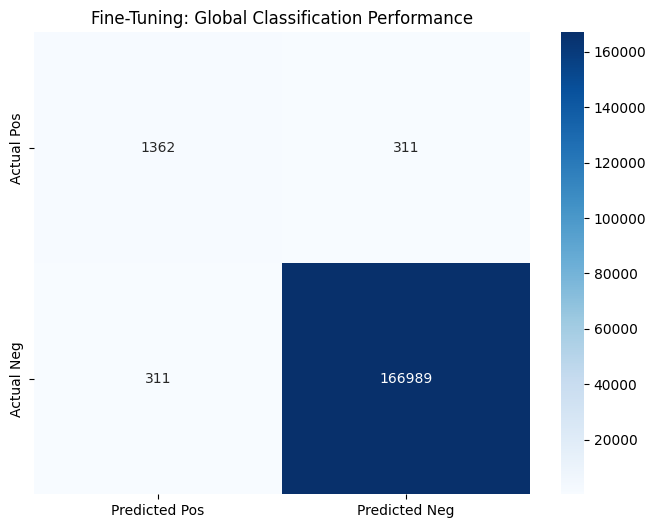

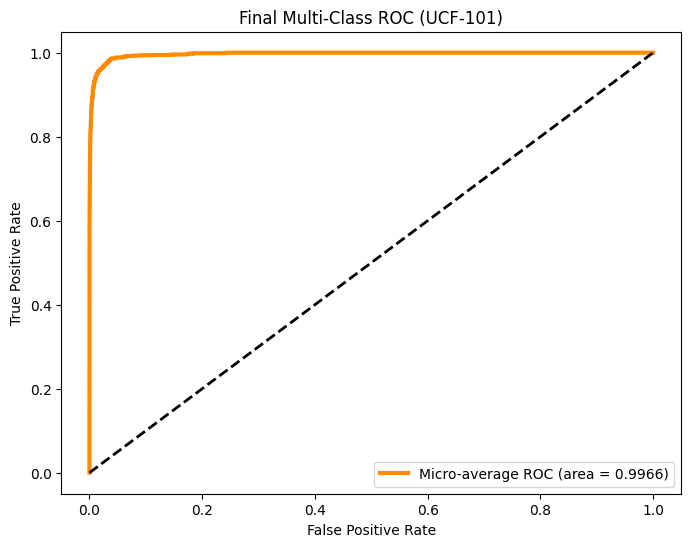

In [72]:
model.eval()
y_true, y_pred, y_probs = [], [], []

with torch.no_grad():
    for frames, labels in val_loader:
        outputs = model(frames.to(device))
        probs = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)
        
        y_true.extend(labels.numpy())
        y_pred.extend(predicted.cpu().numpy())
        y_probs.append(probs.cpu().numpy())

y_probs = np.vstack(y_probs)

# 1. Print Technical Report
print("="*30)
print("FINAL PERFORMANCE REPORT")
print("="*30)
print(classification_report(y_true, y_pred, digits=4))

# 2. Trigger Visuals
plot_final_four_blocks(y_true, y_pred)
plot_final_roc(y_true, y_probs)

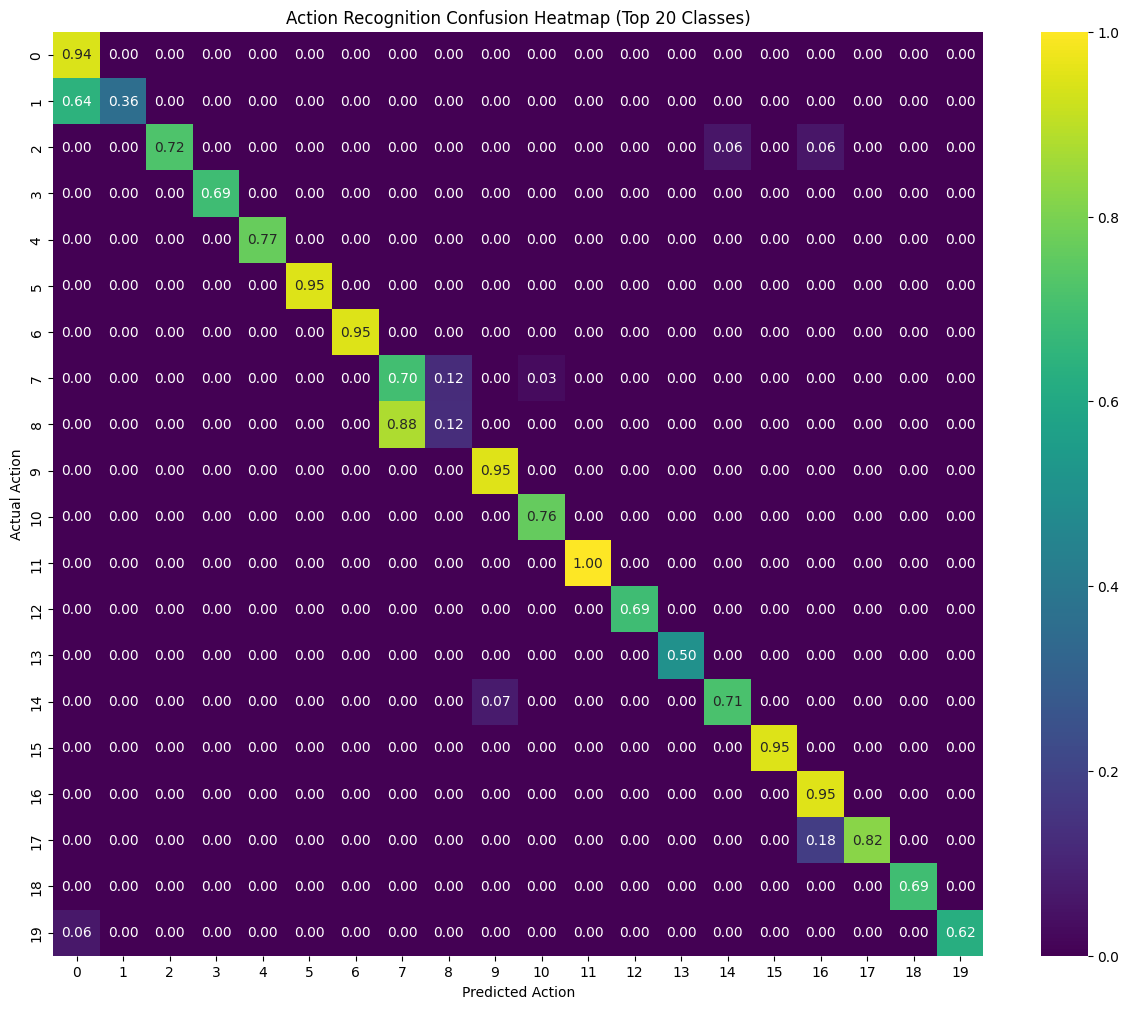

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

def plot_action_heatmap(y_true, y_pred, n_classes=20):
    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Normalize the matrix to show percentages
    cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # Select a subset for readability (First 20 classes)
    plt.figure(figsize=(15, 12))
    sns.heatmap(cm_perc[:n_classes, :n_classes], annot=True, fmt='.2f', cmap='viridis')
    
    plt.title(f'Action Recognition Confusion Heatmap (Top {n_classes} Classes)')
    plt.xlabel('Predicted Action')
    plt.ylabel('Actual Action')
    plt.show()

# Run the plot using the variables from your evaluation loop
plot_action_heatmap(y_true, y_pred, n_classes=20)

In [74]:
from IPython.display import FileLink
# This creates a clickable link to download your best model weights
FileLink('refined_ucf101_model.pth')

/kaggle/working/refined_ucf101_model.pth